### ListOps with Mamba

In [2]:
from __future__ import annotations
from typing import Dict, Any

import torch
from pathlib import Path

from listops_task import ListOpsTask
from src.train_utils.trainer import Trainer

### Configuration
We define a set of hyperparameters and configurations for the training process.
This includes data paths, batch sizes, learning rates, and model-specific parameters.
Using unified block factory from src.utils.block_factory for consistent configuration.

In [10]:
from src.utils.block_factory import make_mamba_block_cfg_ctor

current_dir = Path.cwd()
project_root = current_dir.parent.parent.parent
data_root = str(project_root / "src" / "datasets" / "LRA" / "listOps")

args: Dict[str, Any] = {
    "data_root": data_root,
    "batch": 64,
    "data_loader_kwargs": {
        "num_workers": 0,
        "max_length": 512,
        "pin_memory": False,
        "persistent_workers": False,
    },

    "epochs": 50,
    "lr": 1e-4,
    "wd": 1e-4,
    "grad_clip": 0.5,
    "amp": False,
    "save_dir": "./runs/listops_mamba_task",
    "warmup_epochs": 5,
    "patience": 5,
    "min_delta": 0.001,
    "early_key": "accuracy",

    "d_model": 64,
    "depth": 4,
    "dropout": 0.1,
    "mlp_ratio": 2.0,
    "droppath_final": 0.1,  # ✅ Added droppath for regularization
    "layerscale_init": 1e-2,  # ✅ CRITICAL: Enable LayerScale (was 0.0)
    "residual_gain": 1.0,
    "pool": "mean",

    # Mamba-specific parameters
    "d_state": 8,
    "expand_factor": 2,
    "d_conv": 4,
    "use_external_mlp": True,  # ✅ Enable external MLP for stability

    # ListOps specific
    "max_length": 512,
}

args["block_cfg_ctor"] = make_mamba_block_cfg_ctor(
    d_state=args["d_state"],
    expand_factor=args["expand_factor"],
    d_conv=args["d_conv"],
    use_external_mlp=args["use_external_mlp"],
    dropout=args["dropout"],
    mlp_ratio=args["mlp_ratio"],
    droppath_final=args["droppath_final"],
    layerscale_init=args["layerscale_init"],
    residual_gain=args["residual_gain"],
    pool=args["pool"],
)

if torch.cuda.is_available():
    args["device"] = torch.device("cuda")
    print(f"Using CUDA GPU: {torch.cuda.get_device_name(0)}")
elif torch.backends.mps.is_available():
    args["device"] = torch.device("mps")
    print("Using MPS (Apple Silicon)")
else:
    args["device"] = torch.device("cpu")
    args["amp"] = False
    print("Using CPU")

Using MPS (Apple Silicon)


### Training
With the configuration set up, we can now instantiate the `ListOpsTask` and the `Trainer`.
The `fit` method on the trainer will start the training process, which includes training,
validation, and saving the best model based on the validation accuracy.

In [6]:
from src.utils.visualization import plot_classification_history as plot_history

In [ ]:
task = ListOpsTask()

if torch.backends.mps.is_available() and args["device"].type == "mps":
    torch.mps.set_per_process_memory_fraction(0.9)

trainer = Trainer(args=args, task=task)

best_metric, ckpt_path = trainer.fit()
print(f"Done. Best {trainer.early_key}={best_metric:.4f} @ {ckpt_path}")

ListOps Loaders Created:
  Train: 96000 samples, 1500 batches
  Val:   2000 samples, 32 batches
  Test:  2000 samples, 32 batches
  Max length: 512
  Vocab size: 25
  Classes: 10 (0-9)
Using embedding layer with vocab_size=25
Loaded checkpoint from epoch 41
Val metrics: {'loss': 1.4580339317321778, 'time_s': 2.000244579015998, 'acc': 0.431}


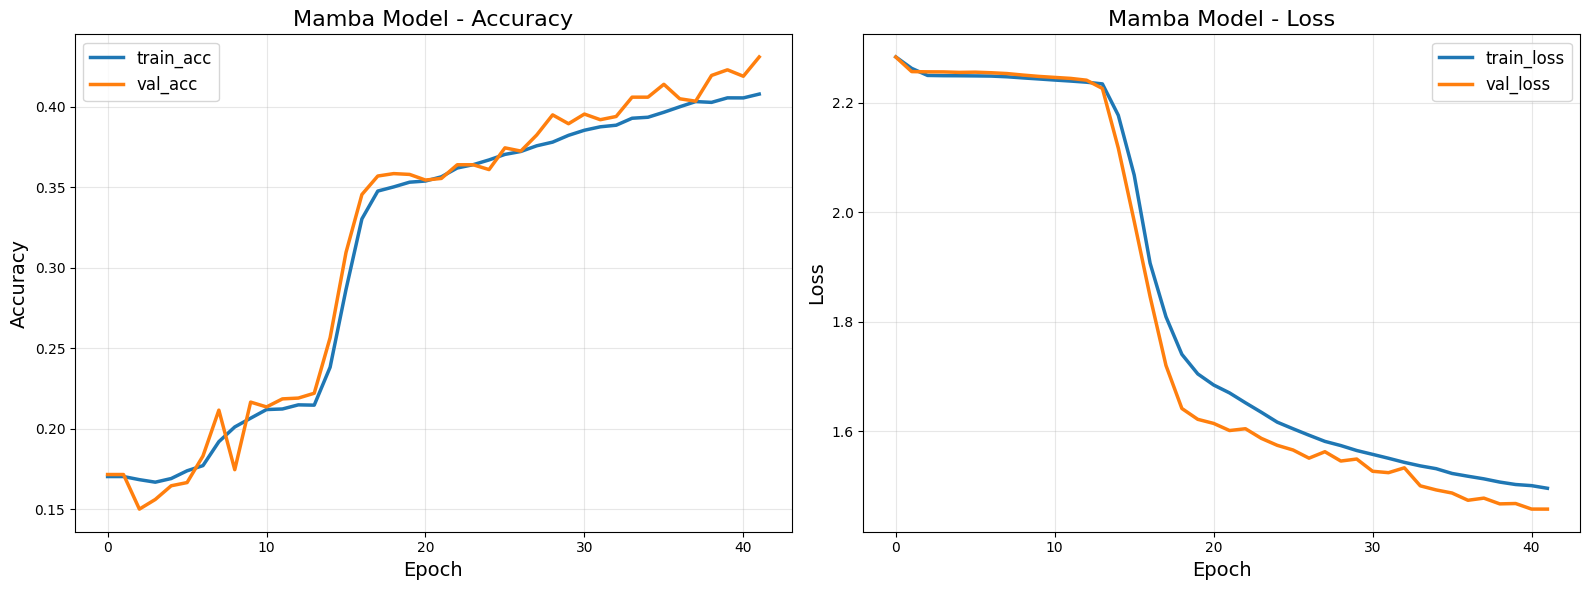

In [11]:
from src.utils.checkpoint import load_trainer_from_checkpoint

trainer = load_trainer_from_checkpoint(
    checkpoint_path=args["save_dir"] + "/best.pt",
    args=args,
    task=ListOpsTask(),
)

history = trainer.history

plot_history(history, model_name="Mamba")

### Evaluation
After training, we can evaluate the best model on the test set.
We load the best model from the checkpoint and then run the evaluation.
The results, including accuracy, are printed.

ListOps Loaders Created:
  Train: 96000 samples, 1500 batches
  Val:   2000 samples, 32 batches
  Test:  2000 samples, 32 batches
  Max length: 512
  Vocab size: 25
  Classes: 10 (0-9)
Using embedding layer with vocab_size=25
Loaded checkpoint from epoch 41
Val metrics: {'loss': 1.4580339317321778, 'time_s': 2.000244579015998, 'acc': 0.431}
ListOps Loaders Created:
  Train: 96000 samples, 1500 batches
  Val:   2000 samples, 32 batches
  Test:  2000 samples, 32 batches
  Max length: 512
  Vocab size: 25
  Classes: 10 (0-9)

 Test results saved to: runs/listops_mamba_task/test_results.json

TEST SET RESULTS
   Accuracy: 0.4285 (42.85%)
   Loss: 1.4501
Overall accuracy: 0.4285
Num classes: 10

Top-10 and Bottom-10 Classes by Performance:
Top per-class accuracies:
01. class_9                   : 0.867
02. class_0                   : 0.840
03. class_4                   : 0.321
04. class_1                   : 0.250
05. class_6                   : 0.206
06. class_7                   : 0.197
0

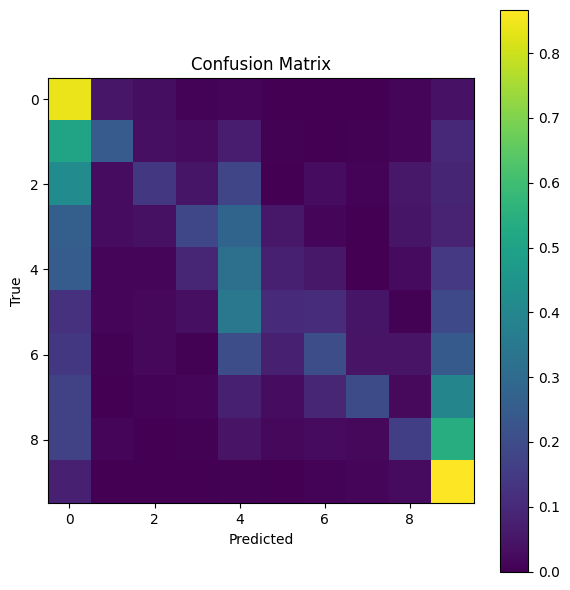

In [12]:
from src.eval.eval_utils import evaluate_classification_model as evaluate_best_model

logits_test, labels_test = evaluate_best_model(
    args=args,
    task=ListOpsTask(),
    best_model_path=f"{args['save_dir']}/best.pt",
    num_classes=10,
    use_test_set=True,
)

### Changes in dataset length

In [ ]:
from src.eval.eval_utils import evaluate_classification_model as evaluate_best_model

if torch.backends.mps.is_available() and args["device"].type == "mps":
    torch.mps.set_per_process_memory_fraction(0.9)


for frac in [0.1, 0.25, 0.5]:
    print(f"\nTraining with fraction: {frac}")

    args["fraction"] = frac
    args["save_dir"] = f"./runs/listops_mamba_task_frac_{int(frac*100)}"
    trainer = Trainer(args=args, task=ListOpsTask())
    best_metric, best_path = trainer.fit()

    print(f"\nTraining complete for fraction {frac}! Best validation {trainer.early_key}: {best_metric:.4f}")
    print(f"Best model saved to: {best_path}")

    history = trainer.history

    plot_history(history, model_name="Mamba")

    logits_test, labels_test = evaluate_best_model(
        args=args,
        task=ListOpsTask(),
        best_model_path=best_path,
        num_classes=10,
        use_test_set=True,
    )